<h2>🚀 NSL-KDD Intrusion Detection - Data Preprocessing & ML Models</h2>

<p>
This notebook demonstrates a full workflow on the <b>NSL-KDD dataset</b>, 
covering preprocessing, scaling, training, and evaluating multiple ML models.
</p>

<h3>Steps covered:</h3>
<ol>
  <li>Load and explore dataset</li>
  <li>Clean missing and duplicate rows</li>
  <li>Handle categorical features with one-hot encoding</li>
  <li>Normalize features using MinMaxScaler</li>
  <li>Create binary target (Normal vs Attack)</li>
  <li>Split into train & test sets</li>
  <li>Train multiple ML models</li>
  <li>Evaluate and compare performance</li>
</ol>


<h3> Step 1: Import Libraries </h3>

In [56]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report



<h3> Step 2: Load Dataset </h3>

In [57]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

file_train_path = "../data/KDDTrain+.txt"
file_test_path = "../data/KDDTest+.txt"

train_df = pd.read_csv(file_train_path, header=None, names=columns)
test_df = pd.read_csv(file_test_path, header=None, names=columns)

print("Train shape:", train_df.shape)
print(train_df.head())


Train shape: (125973, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                     

<h3> Step 3: Data Cleaning </h3>

In [58]:
# Check and drop missing values if any
print("Missing values in train set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Remove duplicates
before_train = train_df.shape[0]
train_df.drop_duplicates(inplace=True)
print(f"Removed {before_train - train_df.shape[0]} duplicates from train set. New shape: {train_df.shape}")

before_test = test_df.shape[0]
test_df.drop_duplicates(inplace=True)
print(f"Removed {before_test - test_df.shape[0]} duplicates from test set. New shape: {test_df.shape}")

# Target column: 0=Normal, 1=Attack
train_df['attack_binary'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack_binary'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)


Missing values in train set: 0
Missing values in test set: 0
Removed 0 duplicates from train set. New shape: (125973, 43)
Removed 0 duplicates from test set. New shape: (22544, 43)


<h3> Step 4: Exploratory Data Analysis (EDA)</h3>


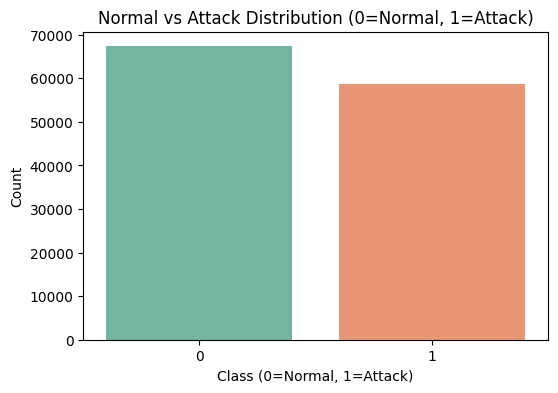

In [59]:
# Normal vs Attack distribution plot 

plt.figure(figsize=(6,4))
sns.countplot(x='attack_binary', data=train_df, hue='attack_binary', palette="Set2", dodge=False, legend=False)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)", fontsize=12)
plt.xlabel("Class (0=Normal, 1=Attack)")
plt.ylabel("Count")
plt.show()


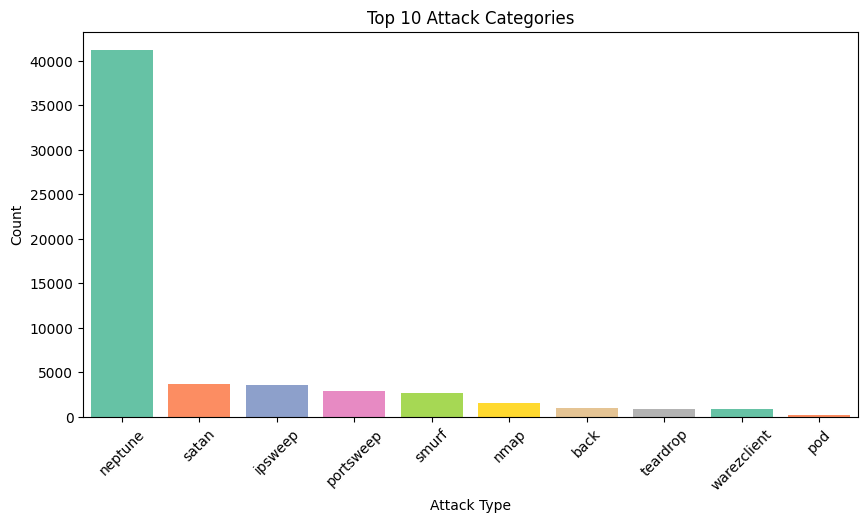

In [60]:
# Top 10 attack categories

attack_counts = train_df[train_df['label'] != 'normal']['label'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=attack_counts.index, y=attack_counts.values) 

colors = sns.color_palette("Set2", len(attack_counts))
for i, bar in enumerate(plt.gca().patches):
    bar.set_facecolor(colors[i])

plt.title("Top 10 Attack Categories", fontsize=12)
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


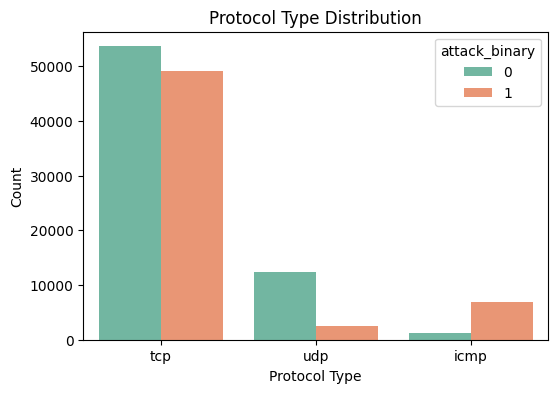

In [61]:
# Protocol distribution by attack_binary
plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=train_df, hue='attack_binary', palette="Set2")
plt.title("Protocol Type Distribution", fontsize=12)
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

In [62]:
#Columns in `train_df` DataFrame
print(train_df.columns)


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level',
       'attack_binary'],
      dtype='object')


<h3> Step 5: One-Hot Encoding </h3>

In [63]:

categorical_cols = ['protocol_type', 'service', 'flag']

train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)


missing_cols = set(train_df.columns) - set(test_df.columns)
for col in missing_cols:
    test_df[col] = 0

test_df = test_df[train_df.columns]


<h3> Step 6: Feature Scaling</h3>


In [64]:
# Scaling
exclude_cols = ['label', 'difficulty_level', 'attack_binary']
numeric_cols = train_df.select_dtypes(include=np.number).columns.difference(exclude_cols)
scaler = MinMaxScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

# Prepare features and target
X_train = train_df.drop(columns=exclude_cols)
y_train = train_df['attack_binary']

X_test = test_df.drop(columns=exclude_cols)
y_test = test_df['attack_binary']


<h3> Step 7: Create Target Variable (Train-Test Split)</h3>



In [65]:
exclude_cols = ['label', 'difficulty_level', 'attack_binary']

X_train = train_df.drop(columns=exclude_cols, axis=1)
y_train = train_df['attack_binary']

X_test = test_df.drop(columns=exclude_cols, axis=1)
y_test = test_df['attack_binary']

print("Training set:", X_train.shape, "Test set:", X_test.shape)


Training set: (125973, 119) Test set: (22544, 119)


<h3> Step 8: Train Multiple Models</h3>


In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))


 Training Logistic Regression...
Logistic Regression Accuracy: 74.38%
              precision    recall  f1-score   support

      Normal       0.64      0.92      0.76      9711
      Attack       0.91      0.61      0.73     12833

    accuracy                           0.74     22544
   macro avg       0.78      0.77      0.74     22544
weighted avg       0.80      0.74      0.74     22544


 Training Decision Tree...
Decision Tree Accuracy: 79.81%
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9711
      Attack       0.96      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544


 Training Random Forest...
Random Forest Accuracy: 76.91%
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.78      9711
      Attack       0.97      0.61      0.75     

<h3> Step 9: Model Accuracy Comparison</h3>


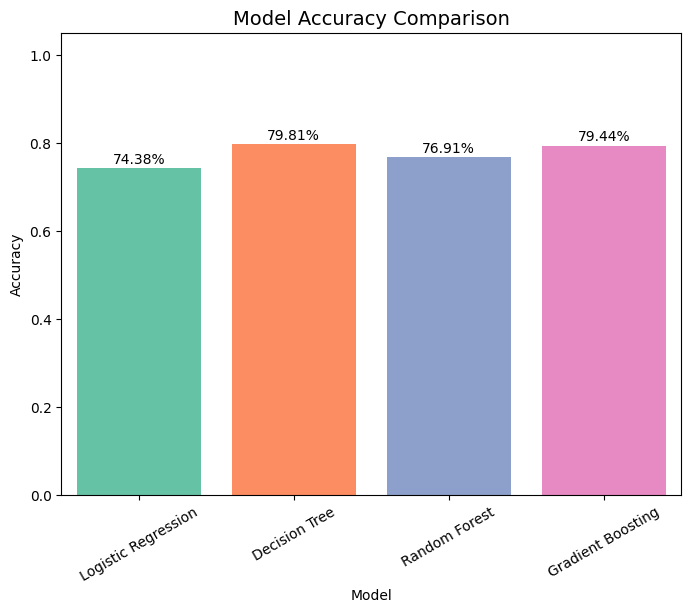

In [67]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(8,6))
barplot = sns.barplot(x='Model', y='Accuracy', data=results_df, dodge=False)  

colors = sns.color_palette("Set2", len(results_df))
for i, bar in enumerate(plt.gca().patches):
    bar.set_facecolor(colors[i])

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(rotation=30)

for bar in plt.gca().patches:
    height = bar.get_height()
    plt.gca().text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height * 100:.2f}%",
        ha='center'
    )
plt.show()


<h3> Step 10: Confusion Matrix (Random Forest)</h3>


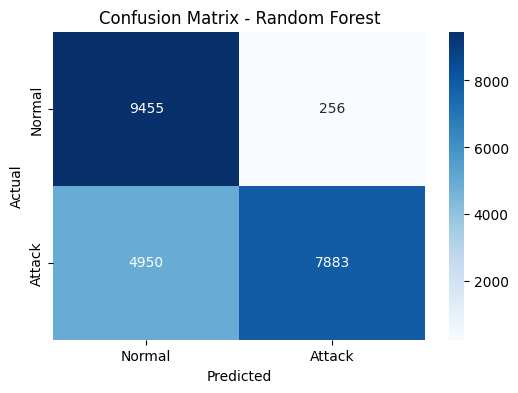

Confusion Matrix Accuracy: 76.91%


In [68]:
from sklearn.metrics import confusion_matrix

best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

accuracy_from_cm = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"Confusion Matrix Accuracy: {accuracy_from_cm * 100:.2f}%")



<h3> Results : a) ROC Curve and AUC Analysis </h3>

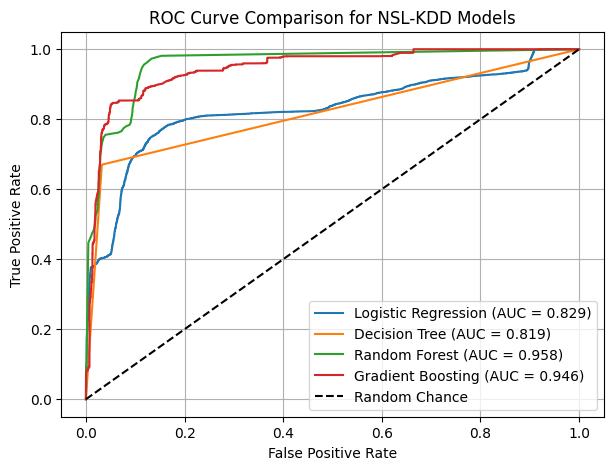

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curve Comparison for NSL-KDD Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


<h3> b) Box Plot </h3>

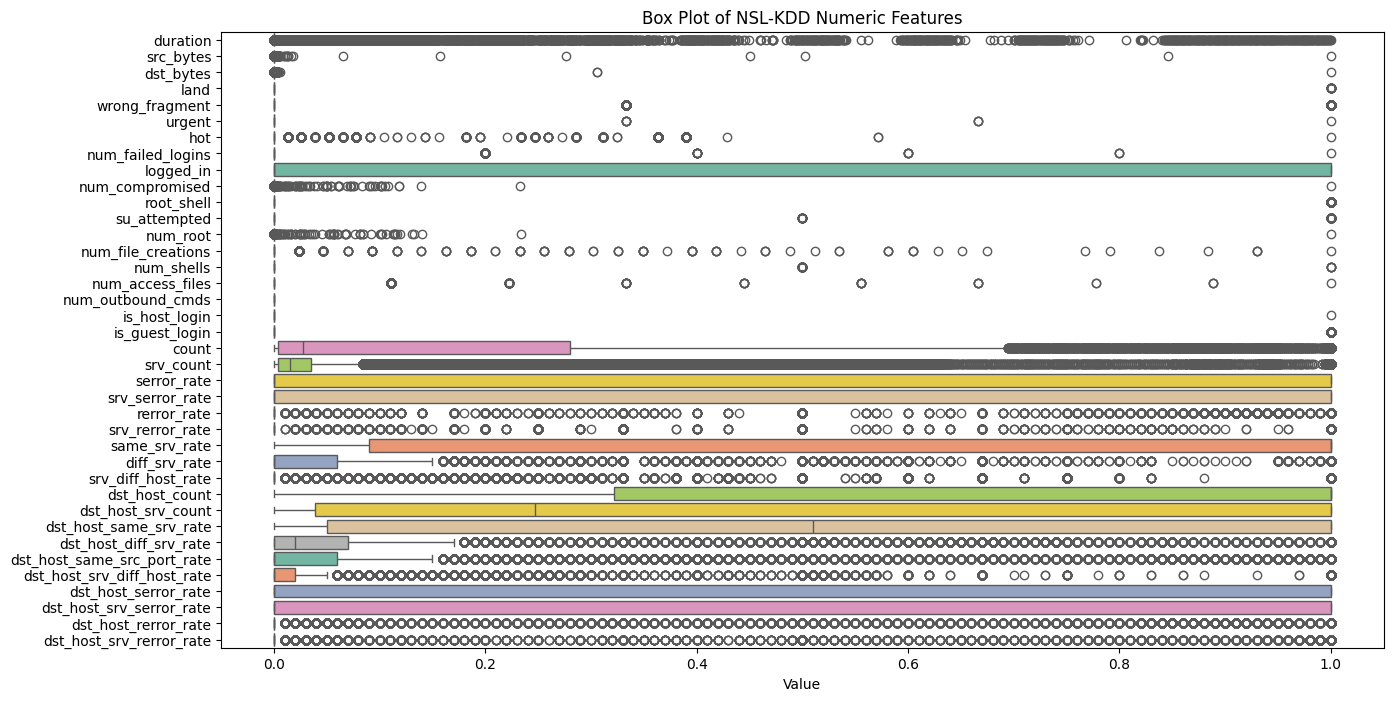

In [73]:

import matplotlib.pyplot as plt

numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=X_train[numeric_cols], orient='h', palette="Set2")
plt.title('Box Plot of NSL-KDD Numeric Features')
plt.xlabel('Value')
plt.show()


<h3> c) Correlation HeatMap </h3>

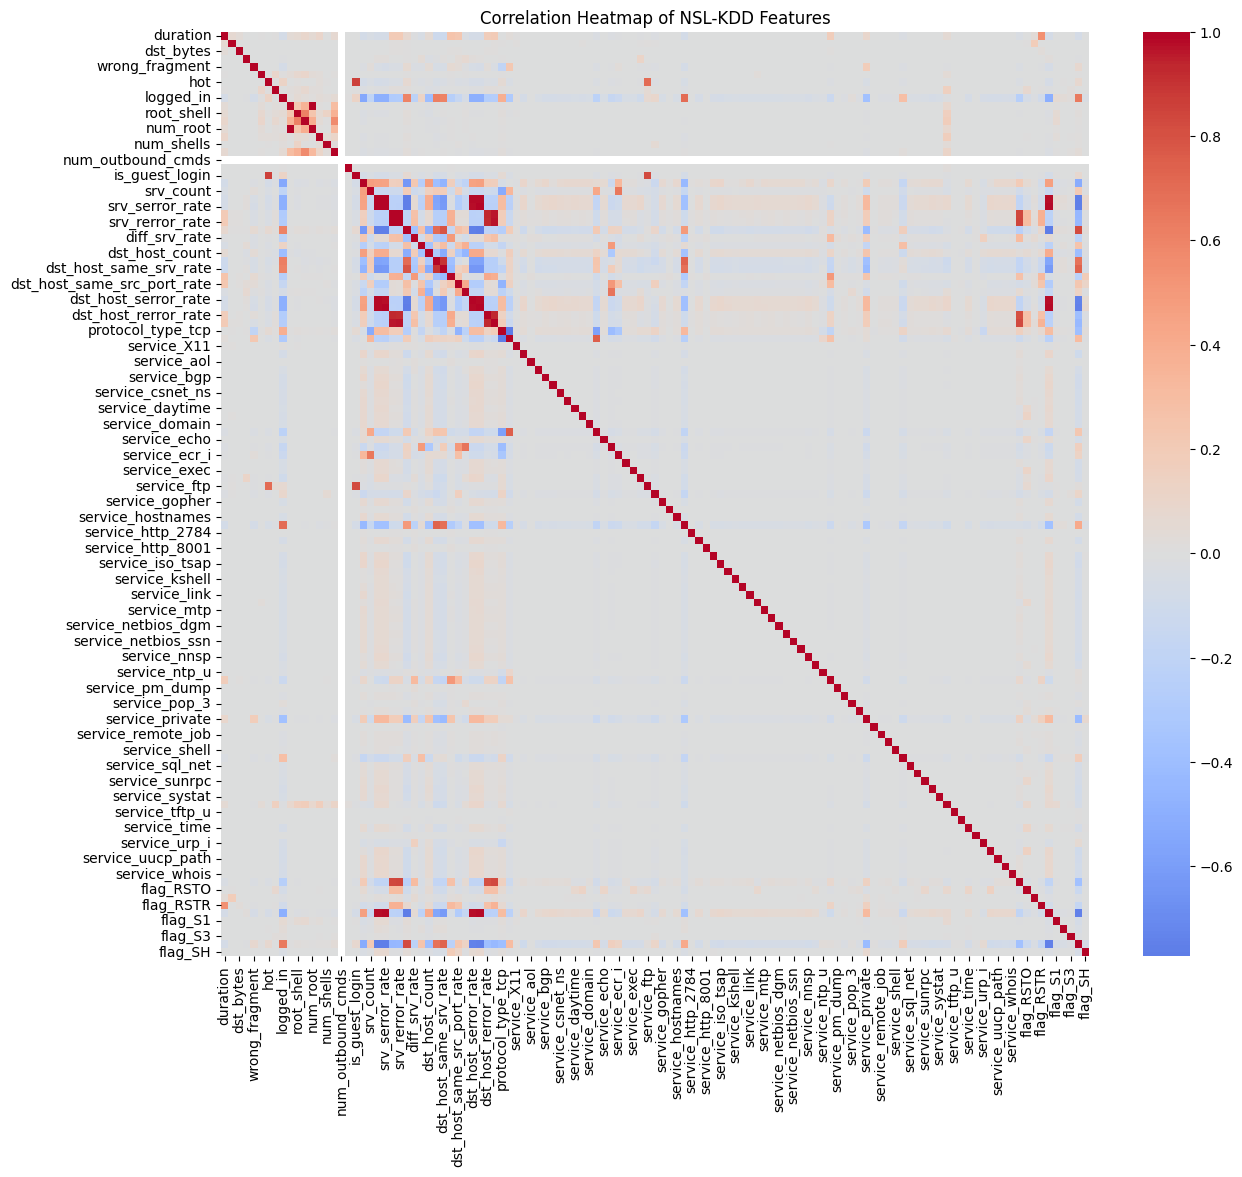

In [71]:
plt.figure(figsize=(14, 12))
corr = X_train.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of NSL-KDD Features')
plt.show()
